In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score

In [26]:
data = pd.read_csv(r"C:\Users\Aqueel Shaikh\Downloads\student_placement_prediction_dataset_2026.csv")

In [27]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [28]:
print(data.head())

   student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1             61.699

In [29]:
print(data['gender'].unique())
print(data['branch'].unique())
print(data['college_tier'].unique())
print(data['placement_status'].unique())

['Male' 'Female']
['IT' 'CSE' 'EEE' 'Civil' 'Mechanical' 'ECE']
['Tier 2' 'Tier 1' 'Tier 3']
['Not Placed' 'Placed']


In [30]:
data = pd.get_dummies(data,columns=["branch","college_tier"],drop_first=True, dtype=int)

In [31]:
data['gender']=data['gender'].map({'Male':0,'Female':1})
data['placement_status']=data['placement_status'].map({'Not Placed':0,'Placed':1})

In [45]:
cols_remove = ["student_id","volunteer_experience", "attendance_percentage", "sleep_hours"]
data = data.drop(columns=[col for col in cols_remove if col in data.columns])

In [33]:
print(data.head())

   age  gender  cgpa  internships_count  projects_count  certifications_count  \
0   24       0  7.53                  4               6                     1   
1   21       0  7.92                  1               3                     6   
2   22       1  8.60                  0               1                     1   
3   24       0  6.68                  0               2                     2   
4   20       1  8.43                  1               4                     3   

   coding_skill_score  aptitude_score  communication_skill_score  \
0           99.238568       81.707722                  57.707166   
1           80.966123       63.116715                  59.197085   
2           49.177184       48.658753                  92.104885   
3           79.359084       66.376653                  83.411798   
4           65.018573       61.274985                  88.956331   

   logical_reasoning_score  ...  study_hours_per_day  placement_status  \
0                59.070073  ..

In [34]:
X = data.drop(columns=["placement_status"])
y = data["placement_status"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())

NaNs in X_train: 0
NaNs in X_test: 0


In [37]:
scale = StandardScaler()
X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.transform(X_test)

In [38]:
nb = GaussianNB()
nb = nb.fit(X_train_scale, y_train)
y_pred_nb = nb.predict(X_test_scale)

In [39]:
knn = KNeighborsClassifier(n_neighbors=3, metric="minkowski", p=2)
knn = knn.fit(X_train_scale, y_train)
y_pred_knn = knn.predict(X_test_scale)

In [40]:
dt = DecisionTreeClassifier(criterion="entropy")
dt = dt.fit(X_train_scale, y_train)
y_pred_dt = dt.predict(X_test_scale)

Confusion Matrix: 
 [[ 9127     0]
 [    0 10873]]


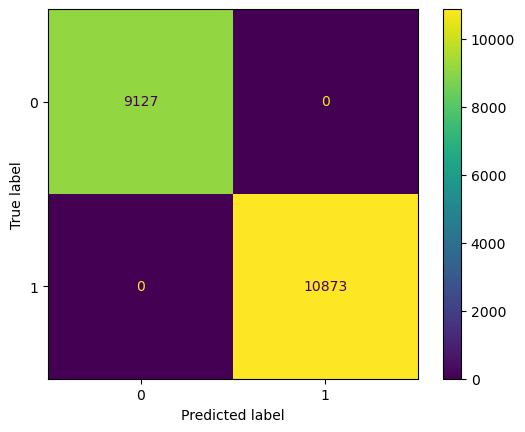

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [41]:
cm = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix: \n",cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print("Accuracy:",accuracy_score(y_test, y_pred_nb))
print("Precision:",precision_score(y_test, y_pred_nb,average="weighted"))
print("Recall:",recall_score(y_test, y_pred_nb,average="weighted"))
print("F1:",f1_score(y_test, y_pred_nb,average="weighted"))

Confusion Matrix for KNN: 
 [[ 8954   173]
 [  146 10727]]


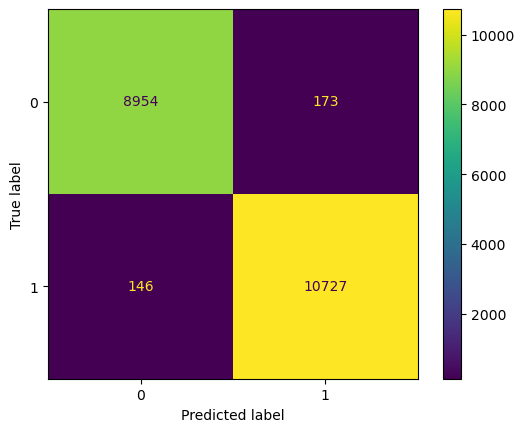

Accuracy: 0.98405
Precision: 0.9840497672648453
Recall: 0.98405
F1: 0.9840480760236867


In [42]:
cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix for KNN: \n",cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print("Accuracy:",accuracy_score(y_test, y_pred_knn))
print("Precision:",precision_score(y_test, y_pred_knn,average="weighted"))
print("Recall:",recall_score(y_test, y_pred_knn,average="weighted"))
print("F1:",f1_score(y_test, y_pred_knn,average="weighted"))

Confusion Matrix for Decision Tree: 
 [[ 9127     0]
 [    0 10873]]


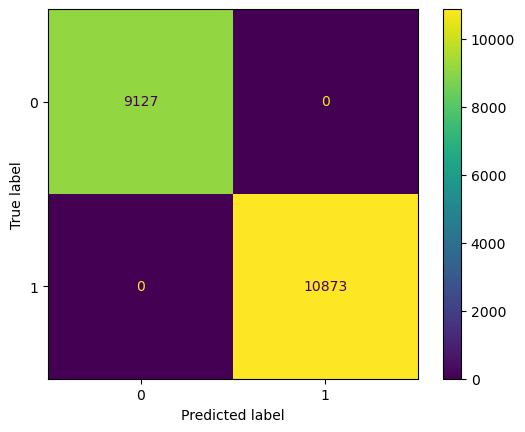

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


In [43]:
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix for Decision Tree: \n",cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print("Accuracy:",accuracy_score(y_test, y_pred_dt))
print("Precision:",precision_score(y_test, y_pred_dt,average="weighted"))
print("Recall:",recall_score(y_test, y_pred_dt,average="weighted"))
print("F1:",f1_score(y_test, y_pred_dt,average="weighted"))